# SO 1036

In [1]:
from DBNets import DBNets2
import matplotlib.pyplot as plt

dbnets = DBNets2()

In [2]:
file_name = '/Users/kaileyliou/Documents/sigma-orionis-dbnets/images/SO1036_continuum_final.image.pbcor.fits'
centre = (998, 998)
inclination = 47.2
pa = 16.2-90
distance = 388.7
rp = 30 # total length/diameter approximately 48 to 56 AU 
res_ba_arcsec = 0.019

In [3]:
res_sigma = res_ba_arcsec/2.355*distance/rp

(np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5))

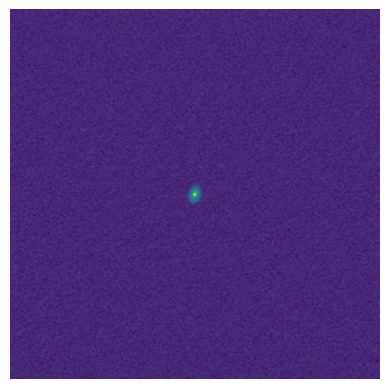

In [4]:
from astropy.io import fits

hdu = fits.open(file_name)[0]
plt.imshow(hdu.data[0,0])
plt.axis('off')

In [5]:
from DBNets import preproc as pp
deproj_image = pp.deproject_image(file_name, distance, inclination, pa, centre, rp)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

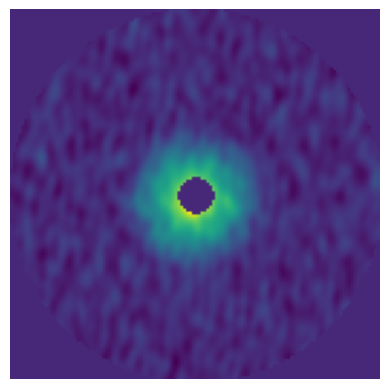

In [6]:
import matplotlib.pyplot as plt
plt.imshow(deproj_image)
plt.axis('off')

In [7]:
samples, cs = dbnets(deproj_image, [res_sigma], nsamples=50000)

100%|███████████████████████████████████| 9988/9988 [00:00<00:00, 14921.24it/s]
10271it [00:00, 18202.63it/s]                                                  
100%|███████████████████████████████████| 9772/9772 [00:00<00:00, 17753.65it/s]
10121it [00:00, 17928.66it/s]                                                  

loading all data and parameters
Sample 10 estimates from the posteriror distribution
Interpolating 10 best estimates
Standardize data
FFT
done.
 Compute metric..
DONE!


In [8]:
import numpy as np
np.median(np.nan_to_num(samples), axis=1)

array([[0.00014607, 0.0652652 , 0.06060625, 0.00011678]])

In [9]:
from DBNets import utils

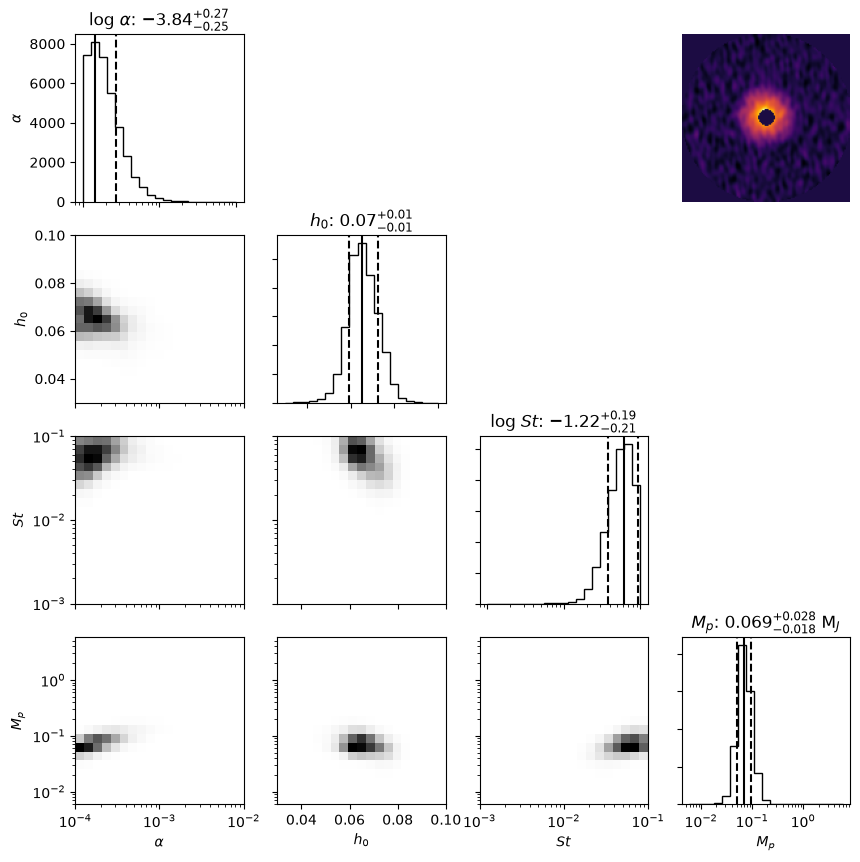

In [10]:
utils.plot_corner(samples[0],name='/Users/kaileyliou/Documents/sigma-orionis-dbnets/images/SO1036_continuum_final.image.pbcor.fits', 
                  savepath='/Users/kaileyliou/Documents/sigma-orionis-dbnets/outputs/so1036.pdf', image = deproj_image, starmass=590)

In [11]:
print(f'Confidence score: {cs[0]:.2f}')

Confidence score: 0.72
